<img src="logo_UNSAM.jpg" align="right" width="120" /> 
<br><br><br><br>
<div style="text-align: center;">

### Analisis y procesamiento de señales 1C 2026
# Trabajo Práctico Nº1

### Melanie amicucci

<br>
</div>

# Introducción:
El objetivo de este trabajo es representar distintas señales analiticas a digitales con cambios de amplitud, desfase, modulación y saturación.
Para poder representar las señales correctamente se necesita considerar la frecuencia de muestreo que debe cumplir con el teorema de nyquist para evitar distorsiones como el aliasing.

# Generar una señal senoidal de 2 kHz de frecuencia
Se generó una señal senoidal a partir de la expresión analitica definida por 
$$
x(t) = A \cdot \sin(2\pi F t + \phi) + DC
$$

donde 
- A es la amplitud de la señal que define el valor máximo
- F es la frecuencia en Hz que indica la cantidad de ciclos por segundo
- t es el tiempo
- $\phi$ : ph en nuestro codigo, es la fase inicial de la señal
- DC: valor medio, el desplazamiento vertical

Se definió el periodo de muestreo como 
$$
t_s = \frac{1}{f_s}
$$ 
donde ${f_s}$ es la frecuencia de muestreo y a partir de el se construye un vector de tiempo discreto.

Se define la función:


In [27]:
import numpy as np  

def mi_funcion_sen(vmax, dc,ff,ph,nn,fs): 

        ts=1/fs 
    
        x = np.arange(nn)
        tt=x*ts
      
        xx=vmax * np.sin (2 * np.pi * ff * tt+ ph) + dc
        
        return tt,xx 

### Frecuencia de Nyquist

Para representar correctamente la señal sin ambigüedades se debe cumplir:

$$
f < f_N=\frac{f_s}{2}
$$

En caso de no cumplirse esta condición, se produce el fenómeno de aliasing, en el cual la señal se distorsiona y puede interpretarse como una frecuencia incorrecta.
<br>
En este primer caso, la señal a sintetizar tiene una frecuencia de 2 kHz. Por lo tanto, la frecuencia de muestreo mínima según el teorema de Nyquist debería ser de al menos 4 kHz. Sin embargo, se utilizó una frecuencia de muestreo de 20 kHz (10 veces la frecuencia de la señal), con el objetivo de obtener una representación más precisa y visualmente más clara de la señal. 

Se definieron los valores de las variables para el primer caso donde la frecuencia toma un valor de 2 Khz
Utilizando los siguientes parametros de la señal:
* Período: $T=\frac{1}{f}= \frac{1}{2000}=0.0005s $
* Número de muestras: $nn=50$

In [28]:
vmax=1
dc=0
ff=2000 #2kHz pasado a Hz=2000
ph=0 
nn=50 #cuantas muestras tomo , aparecen mas ciclo, le bajo para ver menos apretado el grafico 
fs=20000 #por nyquist el minimo de muestras es el doble de la frecuencia, el caso limite es igual. y cuanto mas aumentemos la fs mejor se va a ver la señal 
#10*f es el minimo recoemdable para ver mejor la senoidal
tt,xx1 = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)

# Ampliación y desfase de la señal
A la misma señal sinusoidal se le cambió el valor inicial de la fase dandole un valor inicial $ \frac{\pi}{2} $ y se modificó la amplitud, o sea la escala de la señal 3 db considerando

$3\,\text{dB} = 20 \cdot \log(\frac{v_{max}}{v_{max1}})$
<br>

$ v{max}=10^{3/20} $

             

In [29]:

tt,xx2 = mi_funcion_sen(vmax=1*(10**(3/20)), dc=0,ff=2000,ph=np.pi/2,nn=50,fs=20000)
#la señal debe comportars como un coseno por una identidad sen /x+pi/2) = cos 

# Saturación de la señal 
Definir la saturacion de la señal implica limitar la amplitud cuando supera un valor maximo, en este caso se definió el $75\%$ de la senoidal. 
<br> 
Esto se traduce en que cuando la señal alcanza el rango definido, sus picos se recortan distorsionando la onda original.
Para ello se creó una variable que indique la amplitud maxima que va a tener la señal saturada y otra variable que represente esa señal modulada.
<br>
Se usó la función $np.clip$ que toma la señal original y fuerza todos sus valores a permanecer dentro del intervalo definido, reemplazando aquellos que superan el límite superior por el valor máximo permitido, y aquellos que quedan por debajo del límite inferior por el valor mínimo.

In [30]:

saturacion= vmax * 0.75 #esto es el 75% de la amplitud maxima 

xx3= np.clip(xx1,-saturacion,saturacion) #si le pongo una variable entonces si quiero modificar la amplitud se modifica directamente aca 


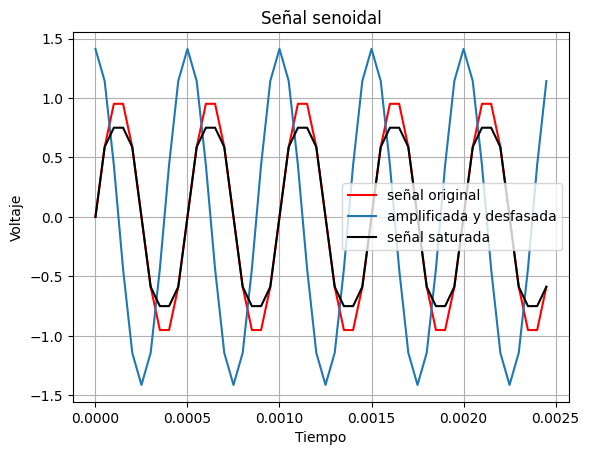

In [31]:
plt.plot(tt, xx1, color='red',label='señal original')
plt.plot(tt,xx2,label='amplificada y desfasada') #eje x:tt , eje y : xx
plt.plot(tt,xx3,color='black', label='señal saturada')
plt.xlabel("Tiempo") #label: nombre a los ejes
plt.ylabel("Voltaje")
plt.title("Señal senoidal") #titulo al 
plt.legend()
plt.grid(True)

En la figura se comparan la señal original, la señal amplificada y desfasada, y la señal saturada. <br> Se observa que la señal amplificada presenta un aumento en su amplitud y un corrimiento en fase respecto de la señal original. Este desfase corresponde a $\frac{\pi}{2}$, por lo que la señal desfasada se comporta como un coseno, cumpliendo la propiedad $\sin(x + \frac{\pi}{2}) = \cos(x)$.<br>
Por otro lado, la señal saturada muestra un recorte en sus picos, mostrando la limitación que se definió en la amplitud.

# Modulación de la senoidal

En esta sección se realizó una modulación en amplitud de la señal original de 2 kHz. Esto se realiza multiplicando la señal original por una sinusoidal de mayor frecuencia, en este caso 1000 kHz.
<br>
El objetivo es trasladar el contenido de la señal original a frecuencias mas altas con una señal envolvente que sigue su forma original.
<br>
Fue necesario aumentar la frecuencia de muestreo ya que la señal portadora tenia una frecuencia alta que necesita mayor muestreo para evitar aliasing.
Utilizando los siguientes parametros de la señal:
* Período: $T=\frac{1}{1000000}=1 µs $
* Número de muestras: $nn=4000$

In [19]:
tt,xxmod = mi_funcion_sen(vmax=1, dc=0,ff=1000000,ph=0,nn=4000,fs=2000001)
tt,xxm2 = mi_funcion_sen(vmax=1, dc=0,ff=2000,ph=0,nn=4000,fs=2000001)

xx_modulada= xxmod * xxm2

Se definió 
* $xxmod$ señal sinusoidal portadora
* $xxm2$ sinusoidal original pero con la cantidad de muestras y la frecuencia de muestreo adecuada para una correcta representacion de la señal modulada
* $xx modulada$  resultado de la señal modulada 


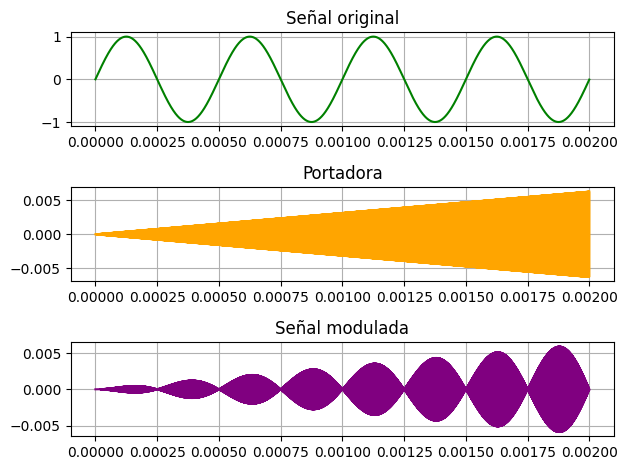

In [20]:
plt.figure()
# Señal original
plt.subplot(3,1,1)
plt.plot(tt, xxm2, color='green')
plt.title("Señal original")
plt.grid(True)
# Portadora
plt.subplot(3,1,2)
plt.plot(tt, xxmod, color='orange')
plt.title("Portadora")
plt.grid(True)
# Señal modulada
plt.subplot(3,1,3)
plt.plot(tt, xx_modulada, color='purple')
plt.title("Señal modulada")
plt.grid(True)

plt.tight_layout()
plt.show()

En el gráfico se comparan la señal original, la señal portadora y la señal modulada donde se puede observar que la señal modulada combina ambas, manteniendo la forma de la señal original en su envolvente y la alta frecuencia de la portadora en sus oscilaciones.

# Señal cuadrada 
Se generó una señal cuadrada a partir de una señal senoidal de frecuencia 4 kHz. Para ello, se utilizó la función signo aplicada a una señal senoidal, la cual toma el valor +1 cuando la señal es positiva y -1 cuando es negativa. 
<br>
Se ajustó la frecuencia de muestreo a 80 kHz para cumplir  con el teorema de Nyquist.
Utilizando los siguientes parametros de la señal:
* Período: $T=\frac{1}{4000}=0.00025s $
* Número de muestras: $nn=100$

In [35]:

def funcion_cuadrada(vmax, dc,ff,ph,nn,fs): 
    ts=1/fs
    
    x = np.arange(nn)
    tt=x*ts
    
    xx_cuadrada = vmax * np.sign(np.sin(2*np.pi*ff*tt +ph))+dc 
    
    return (tt,xx_cuadrada)
vmax=1
dc=0
ff=4000
ph=0 
nn=100
fs=80000 #cambia nyquist porque cambio la frecuencia 

tt_cuadrada,xx_cuadrada = funcion_cuadrada(vmax,dc,ff,ph,nn,fs)

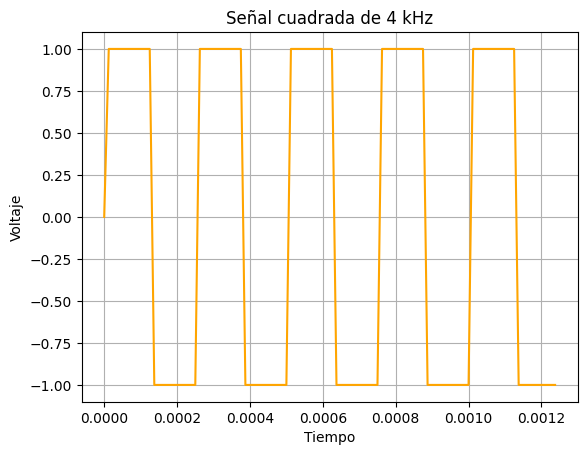

In [37]:
plt.figure()  
plt.plot(tt_cuadrada, xx_cuadrada, label='señal cuadrada', color='orange')
plt.xlabel("Tiempo")
plt.ylabel("Voltaje")
plt.title("Señal cuadrada de 4 kHz")
plt.grid(True)
plt.show()

En el gráfico se observa la señal cuadrada generada a partir de la función signo aplicada a una señal senoidal de 4 kHz. La señal alterna entre dos niveles constantes, representando valores máximos y mínimos bien definidos.

# Pulso rectangular de 10ms 
Un pulso rectangular es aquel que la señal tiene como amplitud una constante, en este caso 1 entre un periodo de tiempo fijo, que definimos como $[0;0.01seg]$ y fuera de él, el valor es nulo.
<br>
Para construir esta señal, se definió un vector de tiempo utilizando la función $np.arange$, la cual genera una secuencia de valores igualmente espaciados. Este vector representa los instantes de tiempo en los cuales se evalúa la señal.
<br>
Luego, se utilizó la función $np.zeros$ para inicializar la señal con valores nulos en todos los instantes. 
<br>
Finalmente, se asignó el valor de amplitud máxima en aquellos instantes donde el tiempo es menor o igual a 10 ms, generando así el pulso rectangular. 

In [40]:
vmax=1 #defino la amplitud maxima del pulso, yo la elegi arbitrariamente
nn_rect=160 #cuanto tiempo total quiero ver
#tiempo total es T=nn/fs, como busco ver por lo menos 0.01 segundo que es lo que dura la señal son los 
fs_rect=8000 #8mil mustras por segundo
ts_rect=1/fs_rect 
tt_rect=np.arange(nn_rect)*ts_rect

xx_pulso = np.zeros(nn_rect) 
#inicialmente toda en cero 

xx_pulso[tt_rect <= 0.01] = 1

Para una visualización cómoda se calculó el tiempo total que se desea ver en el gráfico como la division entre el numero de muestras y la frecuencia de muestreo

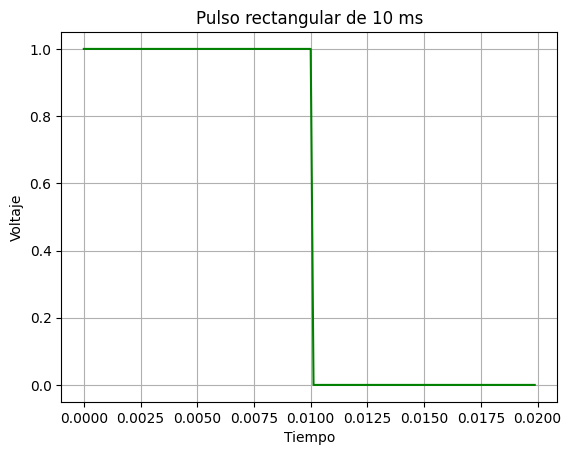

In [39]:
plt.figure()
plt.plot(tt_rect, xx_pulso, color='green')
plt.xlabel("Tiempo")
plt.ylabel("Voltaje")
plt.title("Pulso rectangular de 10 ms")
plt.grid(True)

En la figura se observa el pulso rectangular de duración 10 ms. La señal presenta un valor constante durante el intervalo definido y luego cae abruptamente a cero.

# Analisis y resultados 
A partir de los resultados obtenidos, se puede verificar que la modificación de la amplitud en 3 dB produce un incremento en la señal, tal como se esperaba teóricamente. Además, el desfase aplicado de $\frac{\pi}{2}$ genera un corrimiento temporal que transforma la señal senoidal en una forma equivalente a un coseno, lo cual confirma la correcta implementación del modelo.
<br>
En cuanto a la saturación, se observa que al limitar la señal al $75\%$ de su amplitud máxima, los valores extremos son recortados, produciendo una deformación en la forma de onda.
<br>
La señal cuadrada presenta cambios instantáneos entre sus niveles máximo y mínimo, lo que la diferencia de la señal senoidal, que varía de forma continua. Por otro lado, el pulso rectangular comparte esta característica de cambios abruptos, pero se diferencia en que no es periódico, sino que está definido únicamente en un intervalo de tiempo específico. Durante ese intervalo, la señal mantiene un valor constante, mientras que fuera de él toma el valor cero.
<br>

Para la clasificacion de las señales de potencia o de energía se analiza la periodicidad de cada una. Tanto la senoidal, la cuadrada y la señal modulada son de potencia ya que son periodicas que perduran en el tiempo, en cambio el pulso rectangular es una señal de energía ya que está definida para un intervalo limitado.

<br>
En conjunto, todos los resultados vistos en este informe permiten validar tanto la diferencia entre señales periodicas y no periodicas como la implementación de los conceptos teóricos en las señales digitales.

# EJERCICIO 2
Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:<br>
### a) x[n] = cos(ω₀.n. TS). 
Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

<div style="text-align: center;">
    <img src="ej2_a.jpg" width="600"><br><br>
    <img src="ej2_a2.jpg" width="600"><br><br>

</div>

### b) x[n] = (1/2)ⁿ u[n].
<div style="text-align: center;">    
    <img src="ej2b.jpg" width="600"><br><br>
</div>


### c) x[n] = u[n + 1] - u[n - 2].
<div style="text-align: center;">    
    <img src="ej2c.jpeg" width="600"><br><br>
</div>